## Initialization

In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.integrate import solve_ivp
from astroquery.jplhorizons import Horizons
import matplotlib.dates as mdates
from lamberthub import gooding1990
from astropy.time import Time

AU_KM = 149_597_870.7
DAY_S = 86_400.0

MU_SUN = 2.959122082855911e-4 # AU^3 / day^2
MU_EARTH = 398600.4418  # km^3/s^2
R_EARTH = 6378.1363    # km
R_SOI_EARTH = 924000.0 # km 지구중력권

@dataclass(frozen=True)
class StateVector:
    r: np.ndarray  # position [AU], shape=(3,)
    v: np.ndarray  # velocity [AU/day], shape=(3,)


@dataclass(frozen=True)
class TransferResult:
    # heliocentric spacecraft velocity (au/day)
    v_dep: np.ndarray
    v_arr: np.ndarray

    # planet centered overflow velocity (km/s)
    vinf_dep_vec: np.ndarray
    vinf_arr_vec: np.ndarray

    # -> norm (km/s)
    vinf_dep: float
    vinf_arr: float

    c3: float  #km^2/s^2          
    tof_days: float    

### Mathematical Functions

In [294]:
# 단위벡터
def unit(vector):
    norm = np.linalg.norm(vector)

    return vector / norm 

# 벡터 회전변환 (로드리게스 공식)
def rodrigues(vector, axis, angle_rad):
    axis = unit(axis)

    return (
        vector * np.cos(angle_rad)
        + np.cross(axis, vector) * np.sin(angle_rad)
        + axis * np.dot(axis, vector) * (1 - np.cos(angle_rad))
    )

# 좌표 회전변환 (그래프용)
def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) \
            / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

In [295]:
# 단위 변환 함수 (au/day -> m/s or km/s)
def au_per_day_to_km_per_s(value):
    return np.asarray(value) * AU_KM / DAY_S

def au_per_day_to_m_per_s(value):
    return np.asarray(value) * AU_KM * 1000.0 / DAY_S

# Horizons 데이터에서 가져오기
def state_from_horizons(table, index):
    return StateVector(
        r=np.array(
            [table["x"][index], table["y"][index], table["z"][index]],
            dtype=float,
        ),
        v=np.array(
            [table["vx"][index], table["vy"][index], table["vz"][index]],
            dtype=float,
        ),
    )

# 람베르트 문제 풀기
def solve_lambert(
    earth_dep: StateVector,
    target_arr: StateVector,
    dep_jd: float,
    arr_jd: float,
    *,
    mu: float = MU_SUN,
) -> TransferResult:
    tof_days = float(arr_jd - dep_jd)

    v_sc_departure, v_sc_arrival = gooding1990(
        mu,
        earth_dep.r,
        target_arr.r,
        tof_days,
        M=0,
        prograde=True,
        low_path=True,
    )

    # 출발/도착 기준 초과속도 벡터 (au/day)
    vinf_dep_vec_au_day = v_sc_departure - earth_dep.v
    vinf_arr_vec_au_day = v_sc_arrival - target_arr.v

    # au/day -> km/s
    vinf_dep_vec_km_s = np.asarray(
        au_per_day_to_km_per_s(vinf_dep_vec_au_day),
        dtype=float,
    )
    vinf_arr_vec_km_s = np.asarray(
        au_per_day_to_km_per_s(vinf_arr_vec_au_day),
        dtype=float,
    )

    vinf_dep_km_s = float(np.linalg.norm(vinf_dep_vec_km_s))
    vinf_arr_km_s = float(np.linalg.norm(vinf_arr_vec_km_s))

    return TransferResult(
        v_dep=v_sc_departure,
        v_arr=v_sc_arrival,
        vinf_dep_vec=vinf_dep_vec_km_s,
        vinf_arr_vec=vinf_arr_vec_km_s,
        vinf_dep=vinf_dep_km_s,
        vinf_arr=vinf_arr_km_s,
        c3=vinf_dep_km_s**2,
        tof_days=tof_days,
    )

def get_pareto_front(df):
    df = df.sort_values("c3_km2_s2")

    best_vinf_arr = np.inf
    pareto_indices = []

    for index, row in df.iterrows():
        if row["vinf_arr_km_s"] < best_vinf_arr:
            pareto_indices.append(index)
            best_vinf_arr = row["vinf_arr_km_s"]

    return df.loc[pareto_indices]



### Orbit calc. functions

In [296]:
# 초과속도 벡터로 쌍곡선 궤도 역산
def make_escape_hyperbola(
    vinf_dep_vec,
    parking_alt_km,
    h_hat=None,
):
    # vinf_dep_vec : ndarray, shape (3,) / Lambert 해에서 얻은 지구 기준 출력 초과속도 벡터 [km/s]
    # parking_alt_km : float / 주차궤도 고도 [km]
    # h_hat : ndarray, shape (3,), optional / 탈출 쌍곡선 궤도면의 법선 단위벡터 (none이면 임의)
    
    vinf = np.linalg.norm(vinf_dep_vec)
    s_hat = unit(vinf_dep_vec)

    # 궤도 평면
    if h_hat is None:
        reference = np.array([0.0, 0.0, 1.0])

        # vinf가 z축과 거의 평행하면 다른 기준축 사용
        if abs(np.dot(s_hat, reference)) > 0.99:
            reference = np.array([0.0, 1.0, 0.0])

        h_hat = unit(np.cross(s_hat, reference))
    else:
        h_hat = unit(h_hat)

    # 궤도면 불일치
    if not np.isclose(np.dot(s_hat, h_hat), 0.0, atol=1e-8):
        raise ValueError(
            "h_hat must be perpendicular to vinf_dep_vec "
            "for a coplanar parking-orbit injection."
        )

    r_p = R_EARTH + parking_alt_km

    # 쌍곡선 궤도 요소
    e = 1 + r_p * vinf**2 / MU_EARTH
    f = np.arccos(-1 / e) # 진근점이각

    # 근지점 벡터 계산
    r_hat_p = rodrigues(s_hat, h_hat, -f) # 속도벡터 회전 -> 근지점 설정
    t_hat_p = unit(np.cross(h_hat, r_hat_p)) # 위치벡터 구하기
    v_hyp_p = np.sqrt(vinf**2 + 2 * MU_EARTH / r_p) # 속도 구하기
    v_circ = np.sqrt(MU_EARTH / r_p) # 케플러 속도

    r_p_vec = r_p * r_hat_p # 근지점 위치벡터
    v_hyp_p_vec = v_hyp_p * t_hat_p # 쌍곡선궤도 속도벡터
    v_parking_vec = v_circ * t_hat_p # 주차궤도 속도벡터
    delta_v_tmi_vec = v_hyp_p_vec - v_parking_vec # injection 시 Delta V

    return {
        "r_p_km": r_p_vec,
        "v_hyp_p_km_s": v_hyp_p_vec,
        "v_parking_km_s": v_parking_vec,
        "delta_v_tmi_km_s": delta_v_tmi_vec,

        "r_p_norm_km": np.linalg.norm(r_p_vec),
        "v_hyp_p_norm_km_s": np.linalg.norm(v_hyp_p_vec),
        "delta_v_tmi_norm_km_s": np.linalg.norm(delta_v_tmi_vec),

        "vinf_norm_km_s": vinf,
        "eccentricity": e,
        "f_inf_deg": np.degrees(f),
        "h_hat": h_hat,
    }

# SOI까지
def propagate_to_soi(
    r0_km,
    v0_km_s,
    r_soi_km=R_SOI_EARTH,
):
    y0 = np.hstack((r0_km, v0_km_s))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]

        a = -MU_EARTH * r / np.linalg.norm(r)**3

        return np.hstack((v, a))

    def soi_crossing(_, y):
        r = y[:3]

        return np.linalg.norm(r) - r_soi_km

    soi_crossing.terminal = True
    soi_crossing.direction = 1  # 지구에서 멀어지는 방향만 감지

    solution = solve_ivp(
        rhs,
        (0.0, 10 * 86400.0),  # 최대 10일, 보통 SOI 전에 종료
        y0,
        method="DOP853",
        rtol=1e-12,
        atol=1e-10,
        events=soi_crossing,
    )

    if not solution.t_events[0].size:
        raise RuntimeError("Earth SOI was not reached.")

    return {
        "tof_s": solution.t[-1],
        "tof_days": solution.t[-1] / 86400.0,
        "r_soi_km": solution.y[:3, -1],
        "v_soi_km_s": solution.y[3:, -1],
        "solution": solution,
    }

# 보정값 계산용
def propagate_earth_2body_fixed_time(
    r0_km,
    v0_km_s,
    tof_s,
):
    y0 = np.hstack((r0_km, v0_km_s))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]

        a = -MU_EARTH * r / np.linalg.norm(r)**3

        return np.hstack((v, a))

    solution = solve_ivp(
        rhs,
        (0.0, tof_s),
        y0,
        method="DOP853",
        rtol=1e-12,
        atol=1e-10,
        dense_output=True,
    )

    return {
        "r_km": solution.y[:3, -1],
        "v_km_s": solution.y[3:, -1],
        "solution": solution,
    }

# 보정값 계산
def make_handoff_state(
    escape,
    dv_tangent_km_s=0.0,
    dv_normal_km_s=0.0,
    phase_rad=0.0,
):
    # 주차궤도 내 연소 위치(위상)를 회전
    h_hat = escape["h_hat"]

    r_p_km = rodrigues(
        escape["r_p_km"],
        h_hat,
        phase_rad,
    )

    v_hyp_p_km_s = rodrigues(
        escape["v_hyp_p_km_s"],
        h_hat,
        phase_rad,
    )

    v_parking_km_s = rodrigues(
        escape["v_parking_km_s"],
        h_hat,
        phase_rad,
    )

    # 회전 후 근지점의 국소 좌표계
    r_hat_p = unit(r_p_km)
    t_hat_p = unit(v_hyp_p_km_s)
    n_hat_p = unit(np.cross(r_hat_p, t_hat_p))

    # 접선·법선 보정만 더하므로 r · v = 0 유지
    dv_burn_km_s = (
        dv_tangent_km_s * t_hat_p
        + dv_normal_km_s * n_hat_p
    )

    v_after_burn_km_s = v_hyp_p_km_s + dv_burn_km_s

    handoff = propagate_earth_2body_fixed_time(
        r_p_km,
        v_after_burn_km_s,
        HANDOFF_TOF_S,
    )

    r_handoff_au = (
        earth_soi_state.r
        + handoff["r_km"] / AU_KM
    )

    v_handoff_au_day = (
        earth_soi_state.v
        + handoff["v_km_s"] * DAY_S / AU_KM
    )

    return {
        "r_handoff_au": r_handoff_au,
        "v_handoff_au_day": v_handoff_au_day,

        "r_p_km": r_p_km,
        "v_parking_km_s": v_parking_km_s,
        "v_after_burn_km_s": v_after_burn_km_s,
        "dv_burn_km_s": dv_burn_km_s,

        "soi_radius_offset_km": (
            np.linalg.norm(handoff["r_km"]) - R_SOI_EARTH
        ),

        "r_handoff_km": handoff["r_km"],
        "v_handoff_km_s": handoff["v_km_s"],
        "earth_escape_solution": handoff["solution"],
    }

# 보정값 출력
def print_case(name, case):
    print(f"\n=== {name} ===")
    print("r at handoff [AU]")
    print(case["r_handoff_au"])

    print("v at handoff [AU/day]")
    print(case["v_handoff_au_day"])

    print(
        "SOI radius offset [km]:",
        f"{case['soi_radius_offset_km']:.6f}",
    )

In [297]:
epochs = {
    "start": "2090-01-01",
    "stop": "2110-01-01",
    "step": "1d",
}

earth = Horizons(
    id="399",
    location="@sun",
    epochs=epochs,
)
earth_vec = earth.vectors(refplane="ecliptic")

aa29 = Horizons(
    id="2002 AA29",
    id_type="smallbody",
    location="@sun",
    epochs=epochs,
)
aa29_vec = aa29.vectors(refplane="ecliptic")

In [298]:
DEP_START_INDEX = 0
DEP_STOP_INDEX = 9 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_vec):
            continue

        try:
            transfer = solve_lambert(
                state_from_horizons(earth_vec, dep_index),
                state_from_horizons(aa29_vec, arr_index),
                earth_vec["datetime_jd"][dep_index],
                aa29_vec["datetime_jd"][arr_index],
            )
        except ValueError:
            continue

        results.append({
            "dep_index": dep_index,
            "arr_index": arr_index,

            "dep_jd": earth_vec["datetime_jd"][dep_index],
            "arr_jd": aa29_vec["datetime_jd"][arr_index],
            "tof_days": transfer.tof_days,

            "c3_km2_s2": transfer.c3,
            "vinf_dep_km_s": transfer.vinf_dep,
            "vinf_arr_km_s": transfer.vinf_arr,

            "vinf_dep_x_km_s": transfer.vinf_dep_vec[0],
            "vinf_dep_y_km_s": transfer.vinf_dep_vec[1],
            "vinf_dep_z_km_s": transfer.vinf_dep_vec[2],

            "vinf_arr_x_km_s": transfer.vinf_arr_vec[0],
            "vinf_arr_y_km_s": transfer.vinf_arr_vec[1],
            "vinf_arr_z_km_s": transfer.vinf_arr_vec[2],

            "revolutions": 0,
        })

results_df = pd.DataFrame(results)
pareto_df = get_pareto_front(results_df)


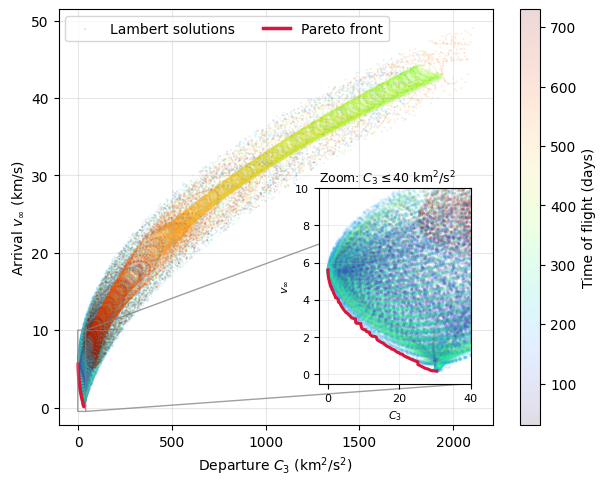

In [299]:
low_c3 = results_df.query("c3_km2_s2 <= 50")
pareto_low = pareto_df.query("c3_km2_s2 <= 50")

fig, ax1 = plt.subplots(figsize=(7, 5.4))

sc = ax1.scatter(
    results_df["c3_km2_s2"],
    results_df["vinf_arr_km_s"],
    c=results_df["tof_days"],
    cmap="turbo",
    s=2,
    alpha=0.15,
    edgecolors="none",
    rasterized=True,
    label="Lambert solutions",
    zorder=1,
)

ax1.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.5,
    label="Pareto front",
    zorder=3,
)

ax1.set_xlabel(r"Departure $C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, loc="upper left")
ax1.grid(alpha=0.3)

ax2 = ax1.inset_axes([0.6, 0.10, 0.35, 0.47])
ax2.set_facecolor("white")

ax2.scatter(
    low_c3["c3_km2_s2"],
    low_c3["vinf_arr_km_s"],
    c=low_c3["tof_days"],
    cmap="turbo",
    s=5,
    alpha=0.15,
    edgecolors="none",
    rasterized=True,
    zorder=1,
)

ax2.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.2,
    zorder=3,
)

ax2.set_xlim(-2.5, 40)
ax2.set_ylim(-0.5, 10)
ax2.set_title(
    r"Zoom: $C_3 \leq 40$ km$^2$/s$^2$",
    loc="left",
    fontsize=9,
    pad=4,
)

ax2.set_xlabel(r"$C_3$", fontsize=8)
ax2.set_ylabel(r"$v_\infty$", fontsize=8)
ax2.tick_params(labelsize=8)
ax2.grid(alpha=0.22)

ax1.indicate_inset_zoom(
    ax2,
    edgecolor="gray",
    alpha=0.75,
    linewidth=1,
)

fig.colorbar(sc, ax=ax1, label="Time of flight (days)")

fig.savefig(
    "v_c3_2100.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

### Select

In [300]:
c3_target = 20

selected = pareto_df.loc[
    (pareto_df["c3_km2_s2"] - c3_target).abs().idxmin()
]

vinf_dep_vec = selected[
    [
        "vinf_dep_x_km_s",
        "vinf_dep_y_km_s",
        "vinf_dep_z_km_s",
    ]
].to_numpy(dtype=float)

print(f"C3 Target    : {c3_target}")
print("---------------------------")
print(f"Departure JD : {selected['dep_jd']:.1f}")
print(f"Arrival JD   : {selected['arr_jd']:.1f}")
print(f"TOF          : {selected['tof_days']:.1f} days")
print(f"C3           : {selected['c3_km2_s2']:.6f} km²/s²")
print(f"Arrival v∞   : {selected['vinf_arr_km_s']:.6f} km/s")
print(f"v∞ vector    : {vinf_dep_vec} km/s")

C3 Target    : 20
---------------------------
Departure JD : 2487522.5
Arrival JD   : 2487737.5
TOF          : 215.0 days
C3           : 19.787771 km²/s²
Arrival v∞   : 1.171324 km/s
v∞ vector    : [-0.0740888866609591 -0.4344437102481988 -4.426459185509728 ] km/s


### Escape parabola construct

In [301]:
DEP_JD = float(selected["dep_jd"])
ARR_JD = float(selected["arr_jd"])

def miss_vector(vec_sc, vec_aa29, arr_jd=ARR_JD):
    df = (
        vec_sc.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
        .sort_values("time")
        .reset_index(drop=True)
    )

    # ARR_JD와 가장 가까운 출력 시점
    row = df.iloc[np.abs(df["time"].to_numpy() - arr_jd).argmin()]

    return np.array([
        row["x_sc"] - row["x_aa29"],
        row["y_sc"] - row["y_aa29"],
        row["z_sc"] - row["z_aa29"],
    ])

PARKING_ALT_KM = 200.0

DV_TEST_KM_S = 1e-5 # normal, tangent
PHASE_TEST_RAD = 1e-6 # phase (rad)

col = ["time", "x", "y", "z", "vx", "vy", "vz"]

escape = make_escape_hyperbola(
    vinf_dep_vec,
    parking_alt_km=PARKING_ALT_KM,
)

earth_escape_nominal = propagate_to_soi(
    escape["r_p_km"],
    escape["v_hyp_p_km_s"],
)

HANDOFF_TOF_S = earth_escape_nominal["tof_s"]
HANDOFF_JD = DEP_JD + earth_escape_nominal["tof_days"]

# 이 시각은 모든 Mercury6 run에서 고정
earth_soi_horizons = Horizons(
    id="399",
    location="@sun",
    epochs=HANDOFF_JD,
)
earth_soi_state_vec = earth_soi_horizons.vectors(
    refplane="ecliptic",
)
earth_soi_state = state_from_horizons(
    earth_soi_state_vec,
    0,
)

print(f"Departure epoch : JD {DEP_JD:.12f}")
print(f"Mercury handoff : JD {HANDOFF_JD:.12f}")
print(f"Handoff duration: {HANDOFF_TOF_S / DAY_S:.9f} days")

Departure epoch : JD 2487522.500000000000
Mercury handoff : JD 2487524.732412126381
Handoff duration: 2.232412126 days


In [302]:
nominal = make_handoff_state(escape)

test_tangent = make_handoff_state(
    escape,
    dv_tangent_km_s=DV_TEST_KM_S,
)

test_normal = make_handoff_state(
    escape,
    dv_normal_km_s=DV_TEST_KM_S,
)

test_phase = make_handoff_state(
    escape,
    phase_rad=PHASE_TEST_RAD,
)

print_case("Run 1: nominal", nominal)
print_case(
    f"Tangent test: +{DV_TEST_KM_S * 1000:.3f} m/s",
    test_tangent,
)
print_case(
    f"Normal test: +{DV_TEST_KM_S * 1000:.3f} m/s",
    test_normal,
)
print_case(
    f"Phase test: +{np.degrees(PHASE_TEST_RAD):.6f} deg",
    test_phase,
)


=== Run 1: nominal ===
r at handoff [AU]
[ 0.218984893111402  -0.993473708383355  -0.0059182258779486]
v at handoff [AU/day]
[ 0.0164776123110262  0.0033919204486737 -0.0026121392660319]
SOI radius offset [km]: -0.000000

=== Tangent test: +0.010 m/s ===
r at handoff [AU]
[ 0.218984892635684  -0.9934737316228257 -0.0059182542998412]
v at handoff [AU/day]
[ 0.016477612078817   0.0033919101599327 -0.0026121531394292]
SOI radius offset [km]: 4.628092

=== Normal test: +0.010 m/s ===
r at handoff [AU]
[ 0.2189848966021198 -0.9934737083833637 -0.0059182259363864]
v at handoff [AU/day]
[ 0.0164776137635691  0.0033919204486699 -0.0026121392903496]
SOI radius offset [km]: 0.000002

=== Phase test: +0.000057 deg ===
r at handoff [AU]
[ 0.2189848930993746 -0.9934737022487481 -0.0059182265965272]
v at handoff [AU/day]
[ 0.0164776123067279  0.0033919230606224 -0.0026121395228364]
SOI radius offset [km]: -0.000001


In [303]:
space_run1_vec = pd.read_csv(
    "SPACECRAFT-run1.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_tangent_vec = pd.read_csv(
    "SPACECRAFT-tangent-1.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_normal_vec = pd.read_csv(
    "SPACECRAFT-normal-1.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_phase_vec = pd.read_csv(
    "SPACECRAFT-phase-1.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

aa29_run1_vec = pd.read_csv(
    "2002AA29-run1.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

dr0 = miss_vector(space_run1_vec, aa29_run1_vec)
dr_tangent = miss_vector(space_tangent_vec, aa29_run1_vec)
dr_normal = miss_vector(space_normal_vec, aa29_run1_vec)
dr_phase = miss_vector(space_phase_vec, aa29_run1_vec)

J0 = np.column_stack([
    (dr_tangent - dr0) / DV_TEST_KM_S,
    (dr_normal - dr0) / DV_TEST_KM_S,
    (dr_phase - dr0) / PHASE_TEST_RAD,
])

du0 = np.linalg.solve(J0, -dr0)

print("TMI tangential correction [m/s]:", du0[0] * 1000)
print("TMI normal correction [m/s]    :", du0[1] * 1000)
print("Parking-orbit phase correction [deg]:",
      np.degrees(du0[2]))

print("\nRun 2 miss [km]:", dr0 * AU_KM)
print("Run 2 miss norm [km]:", np.linalg.norm(dr0) * AU_KM)



TMI tangential correction [m/s]: -25.2720839049471
TMI normal correction [m/s]    : 42.830656715426144
Parking-orbit phase correction [deg]: -0.583830690461398

Run 2 miss [km]: [-75780.57602185705 -88927.62637008868 159401.60354686342]
Run 2 miss norm [km]: 197635.24394027994


In [304]:
run2_case = make_handoff_state(
    escape,
    dv_tangent_km_s=du0[0],
    dv_normal_km_s=du0[1],
    phase_rad=du0[2],
)

print_case("Run 2: corrected", run2_case)

u_run2 = du0.copy()

test_tangent_2 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run2[0] + DV_TEST_KM_S,
    dv_normal_km_s=u_run2[1],
    phase_rad=u_run2[2],
)

test_normal_2 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run2[0],
    dv_normal_km_s=u_run2[1] + DV_TEST_KM_S,
    phase_rad=u_run2[2],
)

test_phase_2 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run2[0],
    dv_normal_km_s=u_run2[1],
    phase_rad=u_run2[2] + PHASE_TEST_RAD,
)

print_case(
    f"Run 2 tangent test: +{DV_TEST_KM_S * 1000:.3f} m/s",
    test_tangent_2,
)

print_case(
    f"Run 2 normal test: +{DV_TEST_KM_S * 1000:.3f} m/s",
    test_normal_2,
)

print_case(
    f"Run 2 phase test: +{np.degrees(PHASE_TEST_RAD):.6f} deg",
    test_phase_2,
)


=== Run 2: corrected ===
r at handoff [AU]
[ 0.2190008788245177 -0.99347691868799   -0.0058392110341201]
v at handoff [AU/day]
[ 0.0164843287792402  0.0033915700528674 -0.0025744770824569]
SOI radius offset [km]: -11717.860499

=== Run 2 tangent test: +0.010 m/s ===
r at handoff [AU]
[ 0.219000878461371  -0.9934769421842726 -0.0058392396956151]
v at handoff [AU/day]
[ 0.0164843285992475  0.0033915596519533 -0.0025744911047605]
SOI radius offset [km]: -11713.186511

=== Run 2 normal test: +0.010 m/s ===
r at handoff [AU]
[ 0.2190008822458898 -0.9934769187627871 -0.0058392111879516]
v at handoff [AU/day]
[ 0.0164843301992063  0.0033915700194774 -0.0025744771539928]
SOI radius offset [km]: -11717.843600

=== Run 2 phase test: +0.000057 deg ===
r at handoff [AU]
[ 0.2190008788124365 -0.9934769126326549 -0.0058392117559088]
v at handoff [AU/day]
[ 0.016484328774936   0.0033915726270466 -0.002574477339612 ]
SOI radius offset [km]: -11717.860499


In [312]:
space_run2_vec = pd.read_csv(
    "SPACECRAFT-run2.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_tangent_2_vec = pd.read_csv(
    "SPACECRAFT-tangent-2.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_normal_2_vec = pd.read_csv(
    "SPACECRAFT-normal-2.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

space_phase_2_vec = pd.read_csv(
    "SPACECRAFT-phase-2.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

dr2 = miss_vector(space_run2_vec, aa29_run1_vec)
dr_tangent_2 = miss_vector(space_tangent_2_vec, aa29_run1_vec)
dr_normal_2 = miss_vector(space_normal_2_vec, aa29_run1_vec)
dr_phase_2 = miss_vector(space_phase_2_vec, aa29_run1_vec)

J2 = np.column_stack([
    (dr_tangent_2 - dr2) / DV_TEST_KM_S,
    (dr_normal_2 - dr2) / DV_TEST_KM_S,
    (dr_phase_2 - dr2) / PHASE_TEST_RAD,
])

du1 = np.linalg.solve(J2, -dr2)
u_run3 = u_run2 + du1


print("TMI tangential correction [m/s]:", du1[0] * 1000)
print("TMI normal correction [m/s]    :", du1[1] * 1000)
print("Parking-orbit phase correction [deg]:",
      np.degrees(du1[2]))

print("\nRun 2 miss [km]:", dr2 * AU_KM)
print("Run 2 miss norm [km]:", np.linalg.norm(dr2) * AU_KM)

TMI tangential correction [m/s]: 0.03162744307933597
TMI normal correction [m/s]    : 0.7486773882154623
Parking-orbit phase correction [deg]: -0.0051237639178069415

Run 2 miss [km]: [-12686.748967908798  -10471.880921095493    2095.1327741313357]
Run 2 miss norm [km]: 16583.228598242804


In [306]:
run3_case = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run3[0],
    dv_normal_km_s=u_run3[1],
    phase_rad=u_run3[2],
)

print_case("Run 3: corrected", run3_case)

test_tangent_3 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run3[0] + DV_TEST_KM_S,
    dv_normal_km_s=u_run3[1],
    phase_rad=u_run3[2],
)

test_normal_3 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run3[0],
    dv_normal_km_s=u_run3[1] + DV_TEST_KM_S,
    phase_rad=u_run3[2],
)

test_phase_3 = make_handoff_state(
    escape,
    dv_tangent_km_s=u_run3[0],
    dv_normal_km_s=u_run3[1],
    phase_rad=u_run3[2] + PHASE_TEST_RAD,
)

print_case("Run 3 tangent test", test_tangent_3)
print_case("Run 3 normal test", test_normal_3)
print_case("Run 3 phase test", test_phase_3)


=== Run 3: corrected ===
r at handoff [AU]
[ 0.2190011349135082 -0.9934775401623243 -0.0058392486829256]
v at handoff [AU/day]
[ 0.0164844349076509  0.0033913044328732 -0.0025745038074752]
SOI radius offset [km]: -11701.801904



=== Run 3 tangent test ===
r at handoff [AU]
[ 0.2190011345524432 -0.9934775636612063 -0.0058392773416829]
v at handoff [AU/day]
[ 0.0164844347286348  0.0033912940306683 -0.0025745178285073]
SOI radius offset [km]: -11697.127981

=== Run 3 normal test ===
r at handoff [AU]
[ 0.2190011383349606 -0.993477540238437  -0.0058392488384364]
v at handoff [AU/day]
[ 0.0164844363276539  0.0033913043988953 -0.002574503879842 ]
SOI radius offset [km]: -11701.784711

=== Run 3 phase test ===
r at handoff [AU]
[ 0.2190011349014167 -0.9934775341069576 -0.0058392494053363]
v at handoff [AU/day]
[ 0.0164844349033422  0.0033913070070765 -0.0025745040648962]
SOI radius offset [km]: -11701.801904


In [313]:
space_run3_vec = pd.read_csv(
    "SPACECRAFT-run3.aei",
    sep=r"\s+",
    skiprows=4,
    names=col,
)

dr3 = miss_vector(space_run3_vec, aa29_run1_vec)

print("\nRun 3 miss [km]:", dr3 * AU_KM)
print("Run 3 miss norm [km]:", np.linalg.norm(dr3) * AU_KM)

r_p = run3_case["r_p_km"]
v_parking = run3_case["v_parking_km_s"]
v_after_burn = run3_case["v_after_burn_km_s"]

# 1. 명목 탈출 쌍곡선에 더한 순수 속도 보정량
dv_correction_km_s = run3_case["dv_burn_km_s"]

# 2. 실제 주차궤도 → 탈출 궤도 총 TMI Δv
dv_tmi_total_km_s = v_after_burn - v_parking

# 3. 보정 후 탈출 C3
r_p_norm = np.linalg.norm(r_p)
v_p_norm = np.linalg.norm(v_after_burn)

c3_corrected = (
    v_p_norm**2
    - 2 * MU_EARTH / r_p_norm
)

vinf_corrected = np.sqrt(c3_corrected)

print("Pure correction Δv [m/s]:",
      np.linalg.norm(dv_correction_km_s) * 1000)

print("Total TMI Δv [km/s]:",
      np.linalg.norm(dv_tmi_total_km_s))

print("Corrected C3 [km²/s²]:",
      c3_corrected)

print("Corrected Earth departure v∞ [km/s]:",
      vinf_corrected)


Run 3 miss [km]: [ 1.4830792022327837  0.2668104121046941 -0.1665995345890995]
Run 3 miss norm [km]: 1.5160696293469542
Pure correction Δv [m/s]: 50.36108620075884
Total TMI Δv [km/s]: 4.064114980203877
Corrected C3 [km²/s²]: 19.19092839955077
Corrected Earth departure v∞ [km/s]: 4.380745187699322


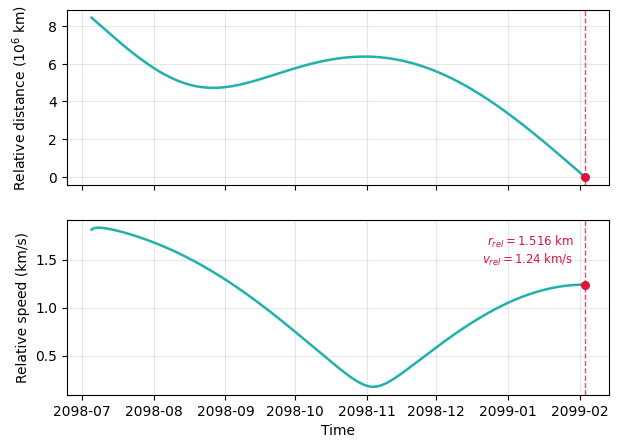

Final distance : 1.5 km
Minimum distance: 1.5 km
Final Δv       : 1.2398 km/s


In [308]:
df = (
    space_run3_vec.merge(aa29_run1_vec, on="time", suffixes=("_sc", "_aa29"))
    .sort_values("time")
    .reset_index(drop=True)
)

time_date = Time(
    df["time"].to_numpy(),
    format="jd",
    scale="tdb",
).to_datetime()

dr_au = np.sqrt(
    (df["x_sc"] - df["x_aa29"])**2
    + (df["y_sc"] - df["y_aa29"])**2
    + (df["z_sc"] - df["z_aa29"])**2
)

dr_km = dr_au * AU_KM
dr_million_km = dr_km / 1e6

dv_km_s = np.sqrt(
    (df["vx_sc"] - df["vx_aa29"])**2
    + (df["vy_sc"] - df["vy_aa29"])**2
    + (df["vz_sc"] - df["vz_aa29"])**2
) * AU_KM / DAY_S

final_time = time_date[-1]
final_distance = dr_km.iloc[-1]
final_speed = dv_km_s.iloc[-1]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 5),
    sharex=True,
)

ax1.plot(time_date, dr_million_km, color="lightseagreen", lw=1.8)
ax1.scatter(
    final_time, final_distance / 1e6,
    color="crimson", s=30, zorder=3,
)
ax1.set_ylabel(r"Relative distance ($10^6$ km)")
ax1.grid(alpha=0.3)

ax2.plot(time_date, dv_km_s, color="lightseagreen", lw=1.8)
ax2.scatter(
    final_time, final_speed,
    color="crimson", s=30, zorder=3,
)
ax2.set_xlabel("Time")
ax2.set_ylabel("Relative speed (km/s)")
ax2.grid(alpha=0.3)

for ax in (ax1, ax2):
    ax.axvline(
        final_time,
        color="crimson",
        ls="--",
        lw=1,
        alpha=0.75,
    )

ax2.annotate(
    f"$r_{{rel}} = {final_distance:.3f}$ km\n"
    f"$v_{{rel}} = {final_speed:.2f}$ km/s",
    xy=(final_time, final_speed),
    xytext=(-8, 12),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=8.5,
    color="crimson",
)
fig.align_ylabels()
fig.savefig(
    "aa29_approach_parameters.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print(f"Final distance : {final_distance:,.1f} km")
print(f"Minimum distance: {dr_km.min():,.1f} km")
print(f"Final Δv       : {final_speed:.4f} km/s")

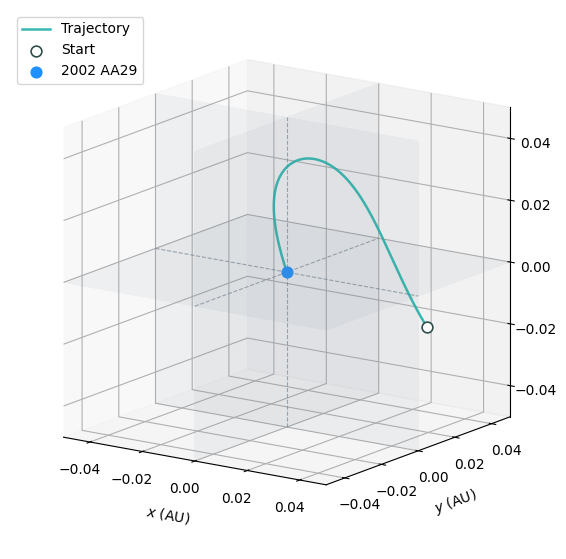

In [309]:
vec_space_rot = get_rotation_coords(space_run4_vec, aa29_run1_vec)

x_rot = np.asarray(vec_space_rot["x"])
y_rot = np.asarray(vec_space_rot["y"])
z_rot = np.asarray(vec_space_rot["z"])

limit = 1.08 * np.max(np.abs(np.concatenate([x_rot, y_rot, z_rot])))

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

plane_axis = np.array([-limit, limit])
p1, p2 = np.meshgrid(plane_axis, plane_axis)

plane_style = {
    "color": "slategray",
    "alpha": 0.07,
    "shade": False,
    "linewidth": 0,
    "antialiased": False,
}

ax.plot_surface(p1, p2, np.zeros_like(p1), **plane_style)
ax.plot_surface(p1, np.zeros_like(p1), p2, **plane_style)
ax.plot_surface(np.zeros_like(p1), p1, p2, **plane_style)

axis_style = {
    "color": "slategray",
    "lw": 0.8,
    "ls": "--",
    "alpha": 0.65,
}

ax.plot([-limit, limit], [0, 0], [0, 0], **axis_style)
ax.plot([0, 0], [-limit, limit], [0, 0], **axis_style)
ax.plot([0, 0], [0, 0], [-limit, limit], **axis_style)

ax.plot(
    x_rot, y_rot, z_rot,
    color="lightseagreen",
    lw=1.8,
    alpha=0.9,
    label="Trajectory",
)

ax.scatter(
    x_rot[0], y_rot[0], z_rot[0],
    color="white",
    edgecolor="darkslategray",
    linewidth=1.2,
    s=60,
    depthshade=False,
    label="Start",
    zorder=4,
)

ax.scatter(
    0, 0, 0,
    color="dodgerblue",
    s=60,
    depthshade=False,
    label="2002 AA29",
    zorder=6,
)

ax.set(
    xlim=(-limit, limit),
    ylim=(-limit, limit),
    zlim=(-limit, limit),
    xlabel="$x$ (AU)",
    ylabel="$y$ (AU)",
    zlabel="$z$ (AU)",
)

ax.xaxis.labelpad = 8
ax.yaxis.labelpad = 8
ax.zaxis.labelpad = 8

ax.view_init(elev=15, azim=-55)
ax.set_proj_type("ortho")
ax.set_box_aspect((1, 1, 1))
ax.grid(alpha=0.3)

ax.legend(loc="upper left")

fig.savefig(
    "aa29_approach_3d.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

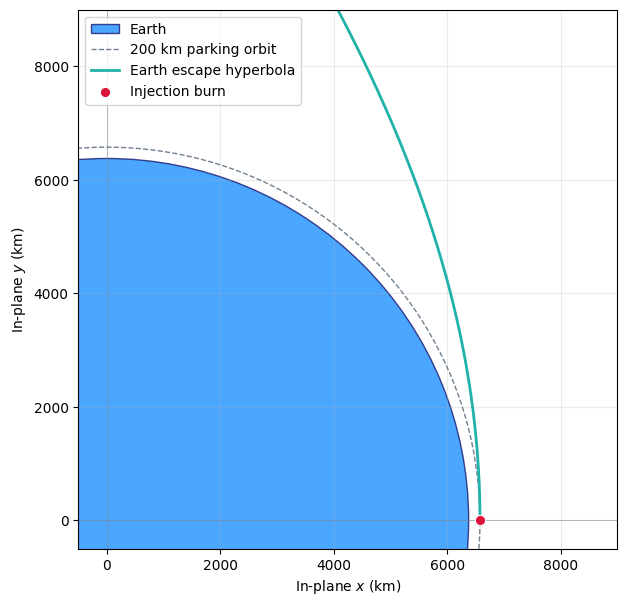

In [311]:
from matplotlib.patches import Circle


# ============================================================
# Earth escape hyperbola: perigee 부근 확대
# ============================================================

escape_solution = run3_case["earth_escape_solution"]

# 근지점 직후에 점을 더 촘촘하게 배치
u = np.linspace(0.0, 1.0, 1_500)
t_plot = HANDOFF_TOF_S * u**2

state_plot = escape_solution.sol(t_plot)

r_geo_km = state_plot[:3].T

# 현재 탈출 쌍곡선의 궤도면 기준 좌표축
r_p_km = run3_case["r_p_km"]
v_p_km_s = run3_case["v_after_burn_km_s"]

r_hat_p = unit(r_p_km)
t_hat_p = unit(v_p_km_s)

# 지구 중심 3D 궤적을 궤도면 2D로 투영
x_km = r_geo_km @ r_hat_p
y_km = r_geo_km @ t_hat_p

r_norm_km = np.linalg.norm(r_geo_km, axis=1)

r_parking_km = R_EARTH + PARKING_ALT_KM

theta = np.linspace(0.0, 2 * np.pi, 400)

fig, ax = plt.subplots(
    figsize=(7, 7),
)

# 지구
earth = Circle(
    (0, 0),
    R_EARTH,
    facecolor="dodgerblue",
    edgecolor="midnightblue",
    linewidth=1.0,
    alpha=0.8,
    label="Earth",
)
ax.add_patch(earth)

# 200 km 원형 주차궤도
ax.plot(
    r_parking_km * np.cos(theta),
    r_parking_km * np.sin(theta),
    color="slategray",
    ls="--",
    lw=1.0,
    label="200 km parking orbit",
)

# 탈출 쌍곡선
ax.plot(
    x_km,
    y_km,
    color="lightseagreen",
    lw=2.0,
    label="Earth escape hyperbola",
)

# 근지점 TMI 연소점
ax.scatter(
    x_km[0],
    y_km[0],
    color="crimson",
    edgecolor="white",
    linewidth=0.8,
    s=55,
    zorder=5,
    label="Injection burn",
)


ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")

ax.axhline(0, color="slategray", lw=0.7, alpha=0.5)
ax.axvline(0, color="slategray", lw=0.7, alpha=0.5)

ax.set(
    xlim=(-500, 9000),
    ylim=(-500, 9000),
    xlabel="In-plane $x$ (km)",
    ylabel="In-plane $y$ (km)",
)

fig.savefig(
    "earth_escape_hyperbola.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()